<a href="https://colab.research.google.com/github/Isabel160609/Cuadernos-colab-Pyton/blob/main/Proyecto_Final_analisis_de_sentimientos(espa%C3%B1ol)v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow #Importamos la libreria tensorflow

In [6]:
!pip install --upgrade tensorflow

Importamos librerias y el archivo que vamos a examinar

In [7]:
# import libraries

import pandas as pd
import numpy as np
import string
import spacy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns
%matplotlib inline
import re
from sklearn.naive_bayes import BernoulliNB
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
from multiprocessing import Pool, cpu_count

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Download necessary NLTK data files
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')



import os
for dirname, _, filenames in os.walk('/content/datos ingles_español.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Examinamos las primeras 10 lineas de las emociones a estudiar (ingles-español) y poder ver las cabeceras del archivo ccv

In [8]:
df=pd.read_csv('/content/datos ingles_español.csv',index_col=0)
df.head(10)

,statement,status,statement_traducido
Unnamed: 0,,,
0,oh my gosh,Anxiety,oh dios mio
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"problemas para dormir, mente confusa, corazón ..."
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"Todo mal, retrocede querido, avanza la duda. Q..."
3,I've shifted my focus to something else but I'...,Anxiety,Cambié mi atención a otra cosa pero todavía es...
4,"I'm restless and restless, it's been a month n...",Anxiety,"Estoy inquieto e inquieto, ya ha pasado un mes..."
5,"every break, you must be nervous, like somethi...",Anxiety,"En cada descanso debes estar nervioso, como si..."
6,"I feel scared, anxious, what can I do? And may...",Anxiety,"Siento miedo, ansiedad, ¿qué puedo hacer? Y qu..."
7,Have you ever felt nervous but didn't know why?,Anxiety,¿Alguna vez te has sentido nervioso pero no sa...
8,"I haven't slept well for 2 days, it's like I'm...",Anxiety,"Llevo 2 días sin dormir bien, es como si estuv..."


Verificamos si el archivo posee algun archivo nulos

In [9]:
print(df.isnull().sum())

statement              362
status                   0
statement_traducido    362
dtype: int64


Corregimos los archivos nulos, eliminandolos de la base de datos



In [10]:
df = df.dropna(subset=['statement'])

Verificamos que ya no queda ningun archivo nulo


In [11]:
print(df.isnull().sum())

statement              0
status                 0
statement_traducido    0
dtype: int64


Verificamos el numero de "emociones" a estudiar

In [12]:
df['status'].nunique()


7

Confirmamos las 7 emociones a estudiar

In [13]:
sentiment_counts=df['status'].value_counts()
print(sentiment_counts)

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


Hace una distribucion de lso registros que tenemos en cada tipo de estado

<Axes: title={'center': 'Distribution of Sentiments'}, xlabel='status'>

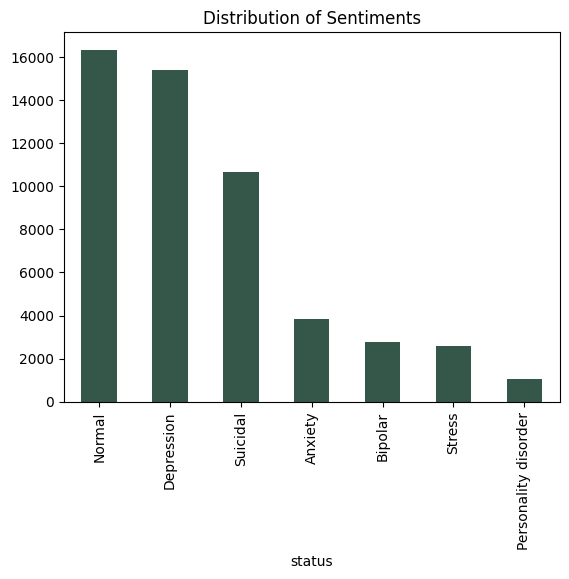

In [14]:
sentiment_counts.plot(kind='bar', title='Distribution of Sentiments', color='#355749')

Verificamos qué tipos de sentimientos u objetivos tiene el modelo por medio de ***un array***



In [15]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

Vemos que tenemos 52681 registros y que cada registro tiene 3 campos (statement, status, y statement_traducido)

In [16]:
df.shape

(52681, 3)

Confirmamos la info que poseemos, las columnas y verificamos que no hay ningun dato nulo


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   statement            52681 non-null  object
 1   status               52681 non-null  object
 2   statement_traducido  52681 non-null  object
dtypes: object(3)
memory usage: 1.6+ MB


Convertimos todos los objetos a ***String*** por que nos sera mas facil trabajar con ellos

In [18]:
df['statement'] = df['statement'].astype('string')
df['status'] = df['status'].astype('string')
df['statement_traducido'] = df['statement_traducido'].astype('string')


Verificamos que todos los datos sean de ***tipo string***

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   statement            52681 non-null  string
 1   status               52681 non-null  string
 2   statement_traducido  52681 non-null  string
dtypes: string(3)
memory usage: 1.6 MB


Generamos un resumen mas compacto de todos los datos en nuestra tabla para poder verlos y entenderlos mas facilmente

In [20]:
df.describe()

,statement,status,statement_traducido
count,52681,52681,52681
unique,51073,7,51011
top,what do you mean?,Normal,¿qué quieres decir?
freq,22,16343,22


Calcula la longitud (la cantidad de caracteres) de cada texto y guardar ese resultado en una columna nueva.

count    52681.000000
mean       612.811754
std        889.099455
min          2.000000
25%         87.000000
50%        336.000000
75%        797.000000
max      31513.000000
Name: statement_length, dtype: float64


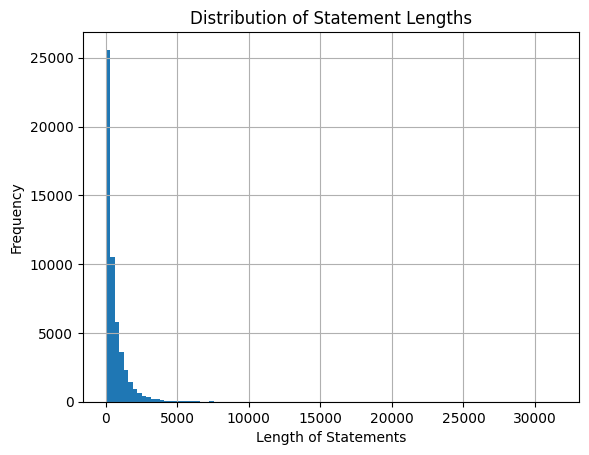

In [21]:
# Calculate the length of each statement
df['statement_length'] = df['statement_traducido'].apply(len)

# Display basic statistics of statement lengths
print(df['statement_length'].describe())

# Plot the distribution of statement lengths
df['statement_length'].hist(bins=100)
plt.title('Distribution of Statement Lengths')
plt.xlabel('Length of Statements')
plt.ylabel('Frequency')
plt.show()

Procedemos a mirar los datos y observamos que hay una frase que se repite una y otra vez, rompiendo el grafico, asi como podemos ver que la frase mas corta no podee sentido alguno.

In [22]:
indice_max = df['statement_length'].idxmax()
print(indice_max)
indice_min = df['statement_length'].idxmin()
print(indice_min)
print(df.loc[indice_max, 'statement_traducido'])
print(df.loc[indice_min, 'statement_traducido'])

13293
2299
No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo soportarlo más. No puedo sopor

Eliminamos la frase mas corta y la mas larga

In [23]:
indice_max = df['statement_length'].idxmax()
indice_min = df['statement_length'].idxmin()
df = df.drop([indice_max, indice_min])

Volvemos a ver como quedaria la grafica sin esos dos valores mas largo/cortos

count    52679.000000
mean       612.236774
std        878.859952
min          2.000000
25%         87.000000
50%        336.000000
75%        797.000000
max      29135.000000
Name: statement_length, dtype: float64


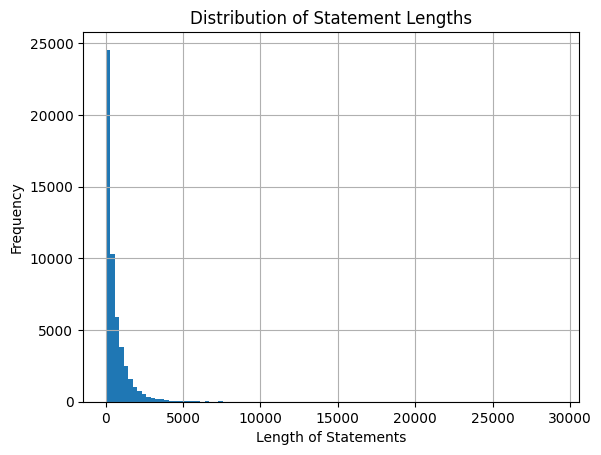

In [24]:
# Calculate the length of each statement
df['statement_length'] = df['statement_traducido'].apply(len)

# Display basic statistics of statement lengths
print(df['statement_length'].describe())

# Plot the distribution of statement lengths
df['statement_length'].hist(bins=100)
plt.title('Distribution of Statement Lengths')
plt.xlabel('Length of Statements')
plt.ylabel('Frequency')
plt.show()

Vemos que siguen habiendo muy cortas y mas, largas, y procedemos a quitar el 25% y 75% de las grafica para hacer la lectura mas simmple

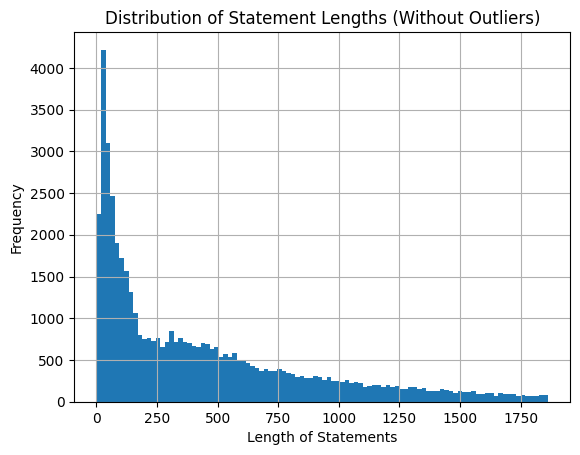

In [25]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['statement_length'].quantile(0.25)
Q3 = df['statement_length'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bound for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
filtered_df = df[(df['statement_length'] >= lower_bound) & (df['statement_length'] <= upper_bound)]
# Plot the distribution of statement lengths without outliers
filtered_df['statement_length'].hist(bins=100)
plt.title('Distribution of Statement Lengths (Without Outliers)')
plt.xlabel('Length of Statements')
plt.ylabel('Frequency')
plt.show()


Instalamos la libreria para poder quitarle los stopwords de manera mas fiable

In [26]:
pip install nltk

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

# Descargar las palabras vacías en español (solo se hace una vez)
nltk.download('stopwords')
stopwords_es = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Creamos la nube de palabras en ingles y español, notando que en ingles el programa detecta mejor las palabras relevantes y se lee las palabras con mas sentido en cada imagen generada, cosa que en español no sucede del todo.

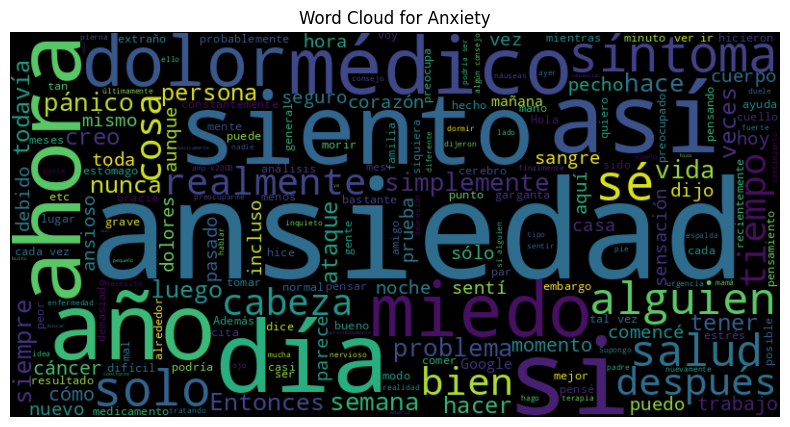

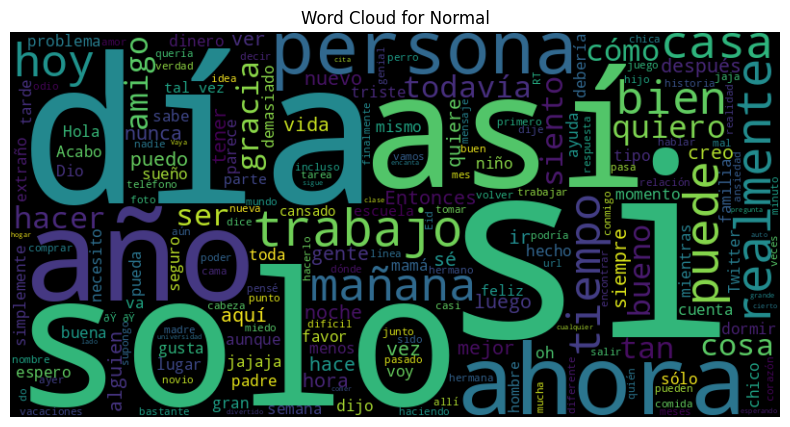

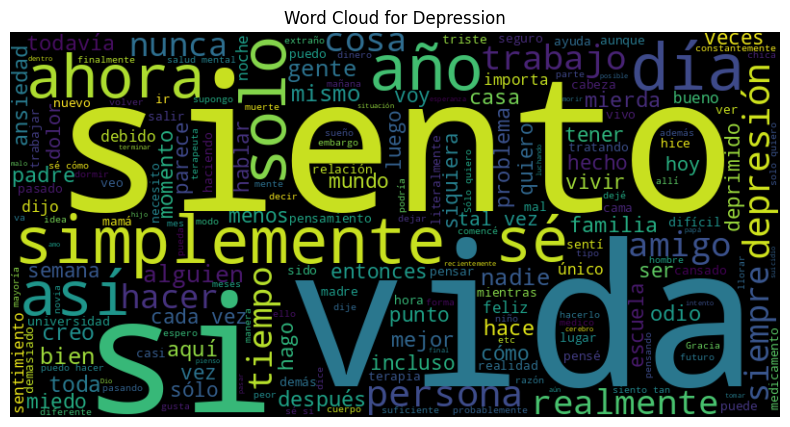

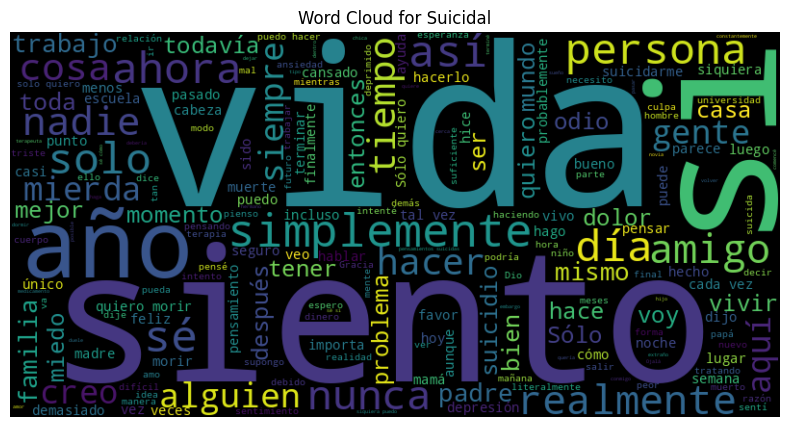

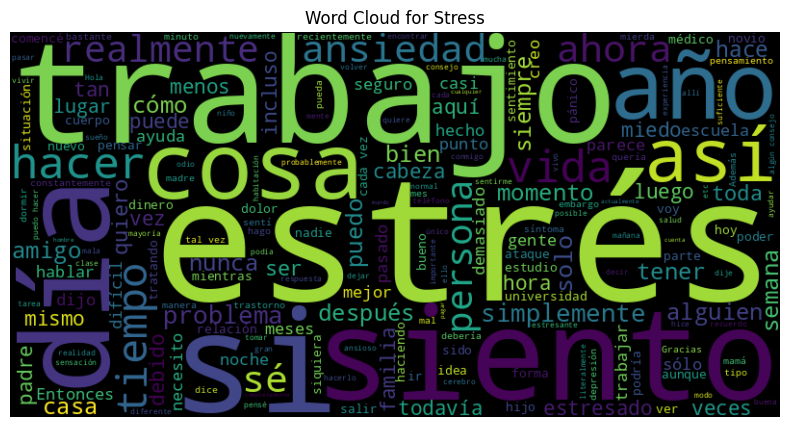

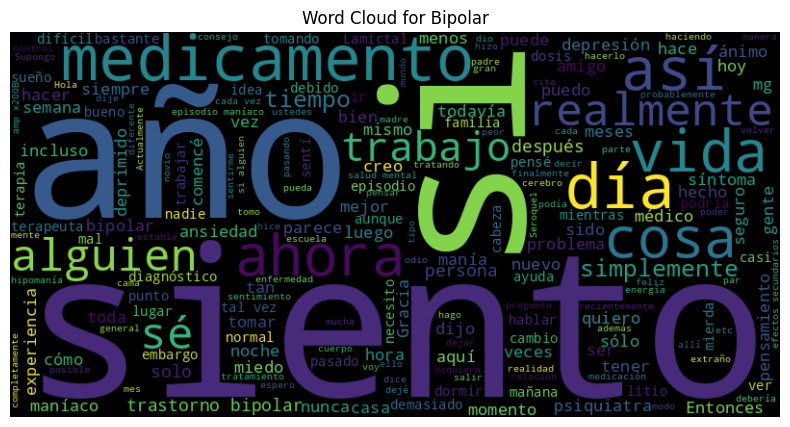

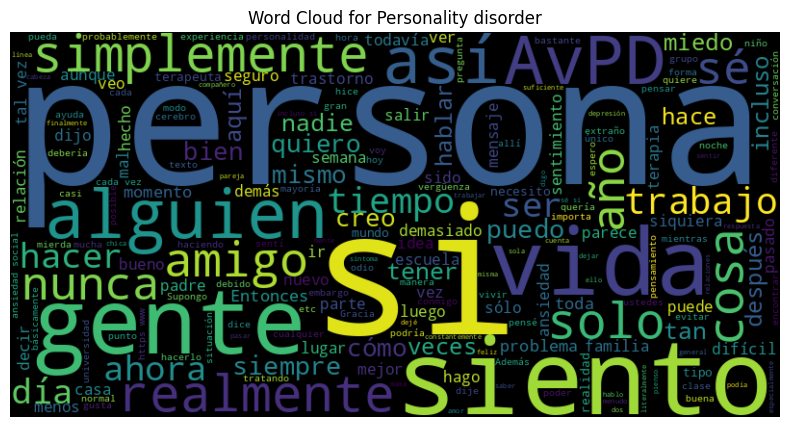

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a function to generate and display a word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, stopwords=stopwords_es).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Generate word clouds for each status
statuses = df['status'].unique()

for status in statuses:
    status_text = ' '.join(df[df['status'] == status]['statement_traducido'])
    generate_word_cloud(status_text, title=f'Word Cloud for {status}')

**Preprocesamiento de texto: Ya que la base de datos es enorme, se procede a transformar el texto para que al algoritmo pueda funcionar mejor a la hora de leerlos, ya que requiere mucho tiempo y energía para procesarlo.**

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
df.head()

,statement,status,statement_traducido,statement_length
Unnamed: 0,,,,
0,oh my gosh,Anxiety,oh dios mio,11
1,"trouble sleeping, confused mind, restless hear...",Anxiety,"problemas para dormir, mente confusa, corazón ...",71
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,"Todo mal, retrocede querido, avanza la duda. Q...",85
3,I've shifted my focus to something else but I'...,Anxiety,Cambié mi atención a otra cosa pero todavía es...,60
4,"I'm restless and restless, it's been a month n...",Anxiety,"Estoy inquieto e inquieto, ya ha pasado un mes...",77


In [31]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
 # Taking a sample of the dataframe, e.g., 20,000 rows
sample_size = 20000
df_sample = df.sample(n=sample_size, random_state=1)

 # Load the spacy model
nlp = spacy.load("es_core_news_sm")
def preprocess_text(text):
     # Convert to lowercase
  text = text.lower()

      # Remove punctuation
  text = text.translate(str.maketrans('', '', string.punctuation))

     # Process text with spacy
  doc = nlp(text)

     # Lemmatize and remove stop words
  tokens = [token.lemma_ for token in doc if not token.is_stop]

     # Join the tokens back into a single string
  return ' '.join(tokens)
def preprocess_texts(texts):
  return [preprocess_text(text) for text in texts]

 # Split the data into batches for multiprocessing
num_cores = cpu_count()
df_split = np.array_split(df_sample, num_cores)

 # Create a multiprocessing Pool
with Pool(num_cores) as pool:
     # Preprocess the text in parallel
    results = pool.map(preprocess_texts, [batch['statement_traducido'].tolist() for batch in df_split])

 # Combine the results
df_sample['cleaned_statement_spanish'] = [item for sublist in results for item in sublist]

 # Display the first few rows of the DataFrame to confirm the changes
print(df_sample[['statement_traducido', 'cleaned_statement_spanish']].head())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


                                          statement_traducido  \
Unnamed: 0                                                      
46842       bipolar/TDAH: busco consejo. Tengo 37 años y t...   
1480        Jessica protagonizó el musical "Legally Blonde...   
47948       Estoy tan cansada que no le veo sentido a mi s...   
19683       Recuerdo todos los momentos más dolorosos. me ...   
37630       está esperando con ansias su próxima sesión de...   

                                    cleaned_statement_spanish  
Unnamed: 0                                                     
46842       bipolartdah busco consejo 37 año bipolar tdah ...  
1480        jessico protagonizar musical legally blonde el...  
47948       cansado ver sentido sufrimiento entender quere...  
19683       recordar momento doloroso carcomeir sentir sal...  
37630       esperar ansia próximo sesión foto trabajar sol...  


In [34]:
df_sample.head()

,statement,status,statement_traducido,statement_length,cleaned_statement_spanish
Unnamed: 0,,,,,
46842,bi-polar /ADHD - looking for advice I'm 37 yea...,Bipolar,bipolar/TDAH: busco consejo. Tengo 37 años y t...,642,bipolartdah busco consejo 37 año bipolar tdah ...
1480,"Jessica starred in the musical ""Legally Blonde...",Normal,"Jessica protagonizó el musical ""Legally Blonde...",100,jessico protagonizar musical legally blonde el...
47948,I’m so tired I just don’t see a point to my su...,Depression,Estoy tan cansada que no le veo sentido a mi s...,569,cansado ver sentido sufrimiento entender quere...
19683,I remember all the most painful moments. it is...,Depression,Recuerdo todos los momentos más dolorosos. me ...,251,recordar momento doloroso carcomeir sentir sal...
37630,is looking forward to her upcoming photo shoot...,Normal,está esperando con ansias su próxima sesión de...,168,esperar ansia próximo sesión foto trabajar sol...


In [35]:
# Extract features and labels
processedtext = df_sample['cleaned_statement_spanish']
sentiment = df_sample['status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(processedtext, sentiment,
                                                    test_size=0.05, random_state=0)

In [37]:
print(f'X_train size: {len(X_train)}')
print(f'X_test size: {len(X_test)}')
print(f'y_train size: {len(y_train)}')
print(f'y_test size: {len(y_test)}')

X_train size: 19000
X_test size: 1000
y_train size: 19000
y_test size: 1000


In [38]:
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train)
print(f'Vectoriser fitted.')
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))

Vectoriser fitted.
No. of feature_words:  446244


In [39]:
X_train = vectoriser.transform(X_train)
X_test  = vectoriser.transform(X_test)

In [40]:
# Use SMOTE to oversample the training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [41]:
# Define the parameter grid
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
}

# Initialize the model
bnb = BernoulliNB()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=bnb, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train_resampled, y_train_resampled)

# Print the best parameters and best score
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_}')

# Train the model with the best parameters
best_bnb = grid_search.best_estimator_
best_bnb.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_best_bnb = best_bnb.predict(X_test)

# Evaluate the model
print("Tuned Bernoulli Naive Bayes")
print(classification_report(y_test, y_pred_best_bnb))


Best Parameters: {'alpha': 0.1}
Best Score: 0.8165732249474793
Tuned Bernoulli Naive Bayes
                      precision    recall  f1-score   support

             Anxiety       0.88      0.30      0.45        73
             Bipolar       1.00      0.13      0.23        54
          Depression       0.50      0.63      0.56       287
              Normal       0.58      0.97      0.73       326
Personality disorder       1.00      0.17      0.29        18
              Stress       1.00      0.16      0.27        44
            Suicidal       0.77      0.20      0.32       198

            accuracy                           0.58      1000
           macro avg       0.82      0.37      0.41      1000
        weighted avg       0.67      0.58      0.52      1000



In [47]:
from sklearn.linear_model import LogisticRegression
import joblib

# Entrenar el modelo balanceado
modelo_balanceado = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_balanceado.fit(X_train_resampled, y_train_resampled)

# Guardarlo con un nombre claro
joblib.dump(modelo_balanceado, "LogisticRegression_Balanced.pkl")

['LogisticRegression_Balanced.pkl']

In [46]:
# import joblib
#  # Supongamos que su modelo entrenado se llama
# 'bernoulli'
#  # Guardamos el modelo en un archivo binario llamado
# 'bernoulli.pkl'

# bnb.fit(X_train_resampled,y_train_resampled )

# joblib.dump(bnb, 'bernoulli.pkl')
#  # Código opcional para descargarlo automáticamente al
#  #ordenador desde Colab
# from google.colab import files
# files.download('bernoulli.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# Ejecuta esto en una celda de Colab para descargar el modelo con vectores reales
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 21.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [46]:

# 1. Suponiendo que tu vectorizador se llama 'vectorizer' (como en los pasos anteriores)
# Guardamos el objeto en un archivo llamado 'vectorizador.pkl'
joblib.dump(vectoriser, 'vectorizador.pkl')

print("✅ ¡Archivo 'vectorizador.pkl' creado y guardado con éxito en tu entorno de Colab!")

✅ ¡Archivo 'vectorizador.pkl' creado y guardado con éxito en tu entorno de Colab!
